In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T

from models.GRNNModel import RGNNPredictor
from Data_Prep.datacreator import prepare_train_test_dataset
from Data_Prep.Graph_Data import Molecule_data
import matplotlib.pyplot as plt

In [2]:
#{'dropout': 0.47781949009481517, 'unfreeze_layers': 7, 'lr': 0.0017709621539926227, 'weight_decay': 5.7858789749948225e-06}
# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
CSV_PATH   = "quinone_molecules.csv"
SMILES_COL = "smiles"
TARGET_COL = "homo_eV"
SAVEPATH   = "processed_dataset/"
BATCH_SIZE = 16
EPOCHS     = 300
SAVE_DIR   = "results"
PRETRAINED = "saved_models/modelHomo.model"

BEST_PARAMS = {
    "dropout":         0.47781949009481517,
    "unfreeze_layers": 7,
    "lr":              0.0017709621539926227,
    "weight_decay":    5.7858789749948225e-06
}


In [3]:
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
def select_device():
    torch.manual_seed(43)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(43)
        idx = 7 if torch.cuda.device_count() > 7 else 0
        print(f"Using cuda:{idx}")
        return f"cuda:{idx}"
    print("Using CPU")
    return "cpu"

In [4]:
# ------------------------------------------------------------
# Data helpers
# ------------------------------------------------------------
def load_molecular_dataframe(csv_path, smiles_col, target_col):
    print("Loading dataset...")
    df = pd.read_csv(csv_path)
    df = df.dropna(axis=1, how="all")
    df = df[df[smiles_col].notna() & df[target_col].notna()]
    df = df[df[smiles_col].astype(str).str.strip() != ""]
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df = df[df[target_col].notna()]
    df = df.rename(columns={smiles_col: "SMILES_str", target_col: "target"})
    print(f"Cleaned shape: {df.shape}")
    return df


def ensure_processed_data(df, savepath):
    train_file = f"data/{savepath}processed/train_data_set.pt"
    test_file  = f"data/{savepath}processed/test_data_set.pt"
    if os.path.isfile(train_file) and os.path.isfile(test_file):
        print("Processed dataset already exists.")
        return
    print("Creating graph dataset...")
    prepare_train_test_dataset(df, "SMILES_str", "target", savepath=savepath)
    print("Graph dataset created.")


def make_loaders(savepath, batch_size):
    transform  = T.Compose([T.NormalizeFeatures(["x", "edge_attr"])])
    train_data = Molecule_data(root=f"data/{savepath}", dataset="train_data_set",
                               y=None, smiles=None, transform=transform)
    test_data  = Molecule_data(root=f"data/{savepath}", dataset="test_data_set",
                               y=None, smiles=None, transform=transform)
    generator = torch.Generator().manual_seed(43)
    val_len   = len(test_data) // 2
    test_len  = len(test_data) - val_len
    val_data, final_test_data = torch.utils.data.random_split(
        test_data, [val_len, test_len], generator=generator
    )
    train_loader = DataLoader(train_data,      batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data,        batch_size=batch_size)
    test_loader  = DataLoader(final_test_data, batch_size=batch_size)
    print(f"train:{len(train_data)}  val:{len(val_data)}  test:{len(final_test_data)}")
    return train_loader, val_loader, test_loader


In [5]:
# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def scatter_plot(trues, preds, split_name, save_dir):
    trues = np.array(trues)
    preds = np.array(preds)

    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2   = r2_score(trues, preds)
    mae  = mean_absolute_error(trues, preds)

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(trues, preds, alpha=0.6, edgecolors="k", linewidths=0.3,
               color="#4C72B0", s=40, label="Samples")

    # Perfect-prediction line
    mn, mx = min(trues.min(), preds.min()), max(trues.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Ideal (y=x)")

    ax.set_xlabel("True Values (eV)",      fontsize=13)
    ax.set_ylabel("Predicted Values (eV)", fontsize=13)
    ax.set_title(f"{split_name} — R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    path = os.path.join(save_dir, f"scatter_{split_name.lower()}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Plot saved → {path}")

In [6]:
# ------------------------------------------------------------
# Model helpers
# ------------------------------------------------------------
def load_pretrained_model(device, dropout):
    model = RGNNPredictor(dropout=dropout).to(device)
    if not os.path.exists(PRETRAINED):
        raise FileNotFoundError(f"Pretrained model not found: {PRETRAINED}")
    model.load_state_dict(torch.load(PRETRAINED, map_location=device))
    print("Loaded pretrained weights.")
    return model


def apply_progressive_unfreezing(model, unfreeze_layers):
    for p in model.parameters():
        p.requires_grad = False
    total = len(model.atom_convs)
    for i in range(max(0, total - unfreeze_layers), total):
        for p in model.atom_convs[i].parameters():    p.requires_grad = True
        for p in model.atom_batchnorms[i].parameters(): p.requires_grad = True
        for p in model.atom_grus[i].parameters():    p.requires_grad = True
    for p in model.mol_conv.parameters(): p.requires_grad = True
    for p in model.mol_gru.parameters():  p.requires_grad = True
    for p in model.lin2.parameters():     p.requires_grad = True


In [7]:
# ------------------------------------------------------------
# Evaluate helper — reused for train/val/test
# ------------------------------------------------------------
def evaluate(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out   = model(batch.x, batch.edge_index, batch.batch)
            preds.extend(out.cpu().numpy().flatten())
            trues.extend(batch.y.cpu().numpy().flatten())
    return np.array(trues), np.array(preds)

In [8]:
# ------------------------------------------------------------
# Training
# ------------------------------------------------------------
def train_model(device, train_loader, val_loader):

    model = load_pretrained_model(device, BEST_PARAMS["dropout"])
    apply_progressive_unfreezing(model, BEST_PARAMS["unfreeze_layers"])

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=BEST_PARAMS["lr"],
        weight_decay=BEST_PARAMS["weight_decay"]
    )

    history = {"epoch": [], "train_loss": [], "val_rmse": [], "val_r2": [], "val_mae": []}
    best_val_rmse = float("inf")
    best_state    = None

    for epoch in range(EPOCHS):
        # Train
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out.view(-1), batch.y.view(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validate
        val_trues, val_preds = evaluate(model, val_loader, device)
        val_rmse = np.sqrt(mean_squared_error(val_trues, val_preds))
        val_r2   = r2_score(val_trues, val_preds)
        val_mae  = mean_absolute_error(val_trues, val_preds)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_rmse"].append(val_rmse)
        history["val_r2"].append(val_r2)
        history["val_mae"].append(val_mae)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d}  TrainLoss {train_loss:.4f}  "
                  f"ValRMSE {val_rmse:.4f}  ValR² {val_r2:.4f}  ValMAE {val_mae:.4f}")

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Restore best weights
    model.load_state_dict(best_state)
    model.to(device)
    return model, history

In [9]:
# ------------------------------------------------------------
# Scatter Plot
# ------------------------------------------------------------
def scatter_plot(trues, preds, split_name, save_dir):
    rmse = np.sqrt(mean_squared_error(trues, preds))
    r2   = r2_score(trues, preds)
    mae  = mean_absolute_error(trues, preds)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(trues, preds, alpha=0.6, edgecolors="k",
               linewidths=0.3, color="#4C72B0", s=40, label="Samples")

    mn, mx = min(trues.min(), preds.min()), max(trues.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Ideal (y=x)")

    ax.set_xlabel("True Values (eV)",      fontsize=13)
    ax.set_ylabel("Predicted Values (eV)", fontsize=13)
    ax.set_title(f"{split_name} — R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    path = os.path.join(save_dir, f"scatter_{split_name.lower()}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Plot saved → {path}")

In [10]:
# ------------------------------------------------------------
# Save Results
# ------------------------------------------------------------
def save_results(model, history, train_loader, test_loader, device):
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Evaluate on train and test
    train_trues, train_preds = evaluate(model, train_loader, device)
    test_trues,  test_preds  = evaluate(model, test_loader,  device)

    # Metrics
    train_metrics = {
        "train_rmse": np.sqrt(mean_squared_error(train_trues, train_preds)),
        "train_r2":   r2_score(train_trues, train_preds),
        "train_mae":  mean_absolute_error(train_trues, train_preds)
    }
    test_metrics = {
        "test_rmse": np.sqrt(mean_squared_error(test_trues, test_preds)),
        "test_r2":   r2_score(test_trues, test_preds),
        "test_mae":  mean_absolute_error(test_trues, test_preds)
    }

    print("\n── Train Results ──")
    for k, v in train_metrics.items(): print(f"  {k}: {v:.4f}")
    print("\n── Test Results ──")
    for k, v in test_metrics.items():  print(f"  {k}: {v:.4f}")

    # Save model
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_finetuned_model.pt"))

    # Save CSVs
    pd.DataFrame(history).to_csv(
        os.path.join(SAVE_DIR, "training_history.csv"), index=False)
    pd.DataFrame({"true": train_trues, "predicted": train_preds}).to_csv(
        os.path.join(SAVE_DIR, "train_predictions.csv"), index=False)
    pd.DataFrame({"true": test_trues, "predicted": test_preds}).to_csv(
        os.path.join(SAVE_DIR, "test_predictions.csv"), index=False)

    # Save metrics JSON
    with open(os.path.join(SAVE_DIR, "test_metrics.json"), "w") as f:
        json.dump({**train_metrics, **test_metrics, "best_params": BEST_PARAMS}, f, indent=2)

    # Scatter plots
    scatter_plot(train_trues, train_preds, "Train", SAVE_DIR)
    scatter_plot(test_trues,  test_preds,  "Test",  SAVE_DIR)

    print(f"\nAll results saved to '{SAVE_DIR}/'")

In [11]:
# ------------------------------------------------------------
# Entry point
# ------------------------------------------------------------

device = select_device()
df     = load_molecular_dataframe(CSV_PATH, SMILES_COL, TARGET_COL)
ensure_processed_data(df, SAVEPATH)
train_loader, val_loader, test_loader = make_loaders(SAVEPATH, BATCH_SIZE)

Using cuda:7
Loading dataset...
Cleaned shape: (30, 7)
Processed dataset already exists.
train:24  val:3  test:3


In [12]:
model, history = train_model(device, train_loader, val_loader)

Loaded pretrained weights.
Epoch    0  TrainLoss 0.4288  ValRMSE 0.5679  ValR² -5.1155  ValMAE 0.4910
Epoch   10  TrainLoss 0.0416  ValRMSE 0.2006  ValR² 0.2372  ValMAE 0.1710
Epoch   20  TrainLoss 0.0178  ValRMSE 0.1638  ValR² 0.4913  ValMAE 0.1271
Epoch   30  TrainLoss 0.0200  ValRMSE 0.1785  ValR² 0.3958  ValMAE 0.1172
Epoch   40  TrainLoss 0.0123  ValRMSE 0.2802  ValR² -0.4890  ValMAE 0.1988
Epoch   50  TrainLoss 0.0096  ValRMSE 0.1783  ValR² 0.3973  ValMAE 0.1395
Epoch   60  TrainLoss 0.0256  ValRMSE 0.2325  ValR² -0.0252  ValMAE 0.1576
Epoch   70  TrainLoss 0.0025  ValRMSE 0.2331  ValR² -0.0303  ValMAE 0.1573
Epoch   80  TrainLoss 0.0029  ValRMSE 0.1387  ValR² 0.6354  ValMAE 0.1087
Epoch   90  TrainLoss 0.0078  ValRMSE 0.1427  ValR² 0.6138  ValMAE 0.1080
Epoch  100  TrainLoss 0.0045  ValRMSE 0.1558  ValR² 0.5399  ValMAE 0.1209
Epoch  110  TrainLoss 0.0040  ValRMSE 0.1645  ValR² 0.4870  ValMAE 0.1323
Epoch  120  TrainLoss 0.0072  ValRMSE 0.1546  ValR² 0.5468  ValMAE 0.1162
Epoch  


── Train Results ──
  train_rmse: 0.0380
  train_r2: 0.9913
  train_mae: 0.0271

── Test Results ──
  test_rmse: 0.2606
  test_r2: -0.8785
  test_mae: 0.1748


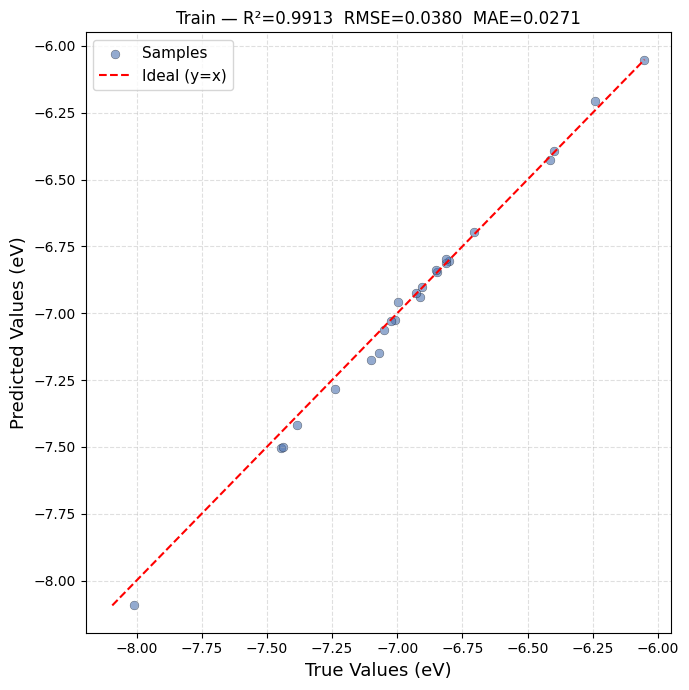

Plot saved → results/scatter_train.png


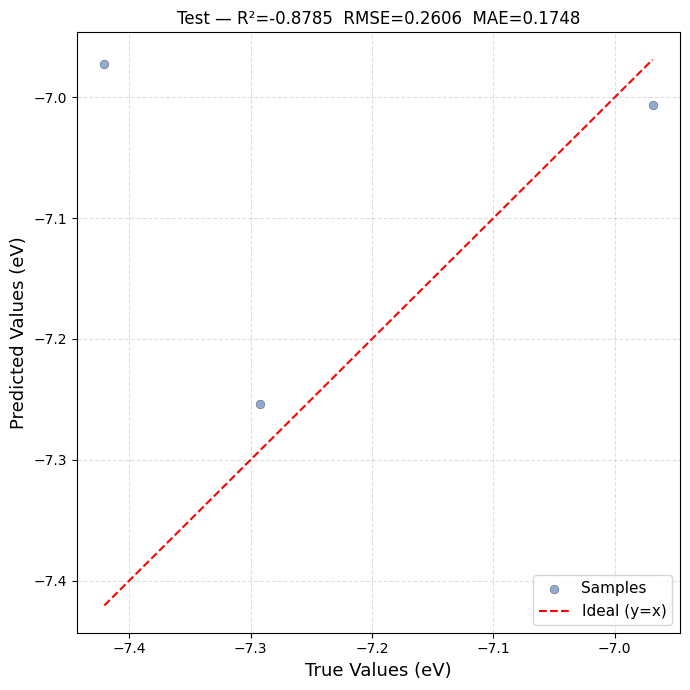

Plot saved → results/scatter_test.png

All results saved to 'results/'


In [13]:
save_results(model, history, train_loader, test_loader, device)